In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from Abelian_Potential import Abelian_Model
from scipy.optimize import minimize_scalar

## Define the Model

In [258]:
# Parameters: strong FOPT regime (large g/sqrt(lam) ratio)
lam, mu, g = 0.05, 50.0, 1.0

model = Abelian_Model(lam, mu, g)

# Analytic expectations
v_tree  = mu / np.sqrt(lam)
mh_tree = np.sqrt(2.0) * mu
mA_tree = g * v_tree
print(f"Tree-level vev :  v  = {v_tree:.3f} GeV")
print(f"Tree-level Higgs: mh = {mh_tree:.3f} GeV")
print(f"Tree-level gauge: mA = {mA_tree:.3f} GeV")

# Numerical vev from Vtot(T=0)
T_eps = 1e-6  # numerically zero, avoids division by T=0

res = minimize_scalar(
    lambda phi: model.Vtot(np.array([[phi]]), T_eps).item(),
    bounds=(50, 350),
    method='bounded'
)
v_num = res.x
print(f"\nNumerical vev (Vtot, T=0): {v_num:.3f} GeV")
print(f"CW shift: {abs(v_num - v_tree)/v_tree * 100:.3f}%  (expected small)")

Tree-level vev :  v  = 223.607 GeV
Tree-level Higgs: mh = 70.711 GeV
Tree-level gauge: mA = 223.607 GeV

Numerical vev (Vtot, T=0): 243.117 GeV
CW shift: 8.725%  (expected small)


## Coleman Weinberg ($T=0$)

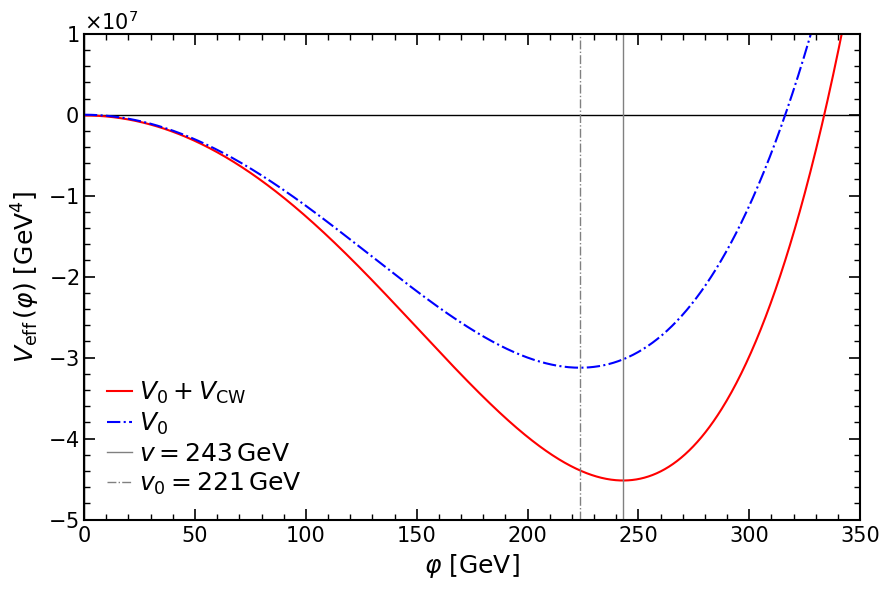

In [270]:
phi_vals = np.linspace(-50, 500, 1500)
X        = phi_vals[:, np.newaxis] 

V_tree   = model.V0(X)
V_tot_0  = model.Vtot(X, 0.0)

fig, ax = plt.subplots(figsize=(9, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(phi_vals, V_tot_0, label=r'$V_0 + V_\mathrm{CW}$', color='r', lw=1.5, ls='-')
ax.plot(phi_vals, V_tree, label=r'$V_0$', color='b', lw=1.5, ls='-.')

ax.axvline(v_num, label=rf'$v={float(np.squeeze(v_num)):.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.0, ls='-', alpha=1)
ax.axvline(v_tree, label=rf'$v_0={v_analytic:.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.0, ls='-.', alpha=1)

ax.set_xlim(0, 350)
ax.set_ylim(-5e7,1e7)

ax.set_xlabel(r'$\varphi$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_\mathrm{eff}\,(\varphi)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

# Configure ticks
ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=5)

plt.legend(fontsize=18, frameon=True, fancybox=False,
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig("figures\Abelian_CW.pdf", format="pdf", bbox_inches="tight")

plt.show()

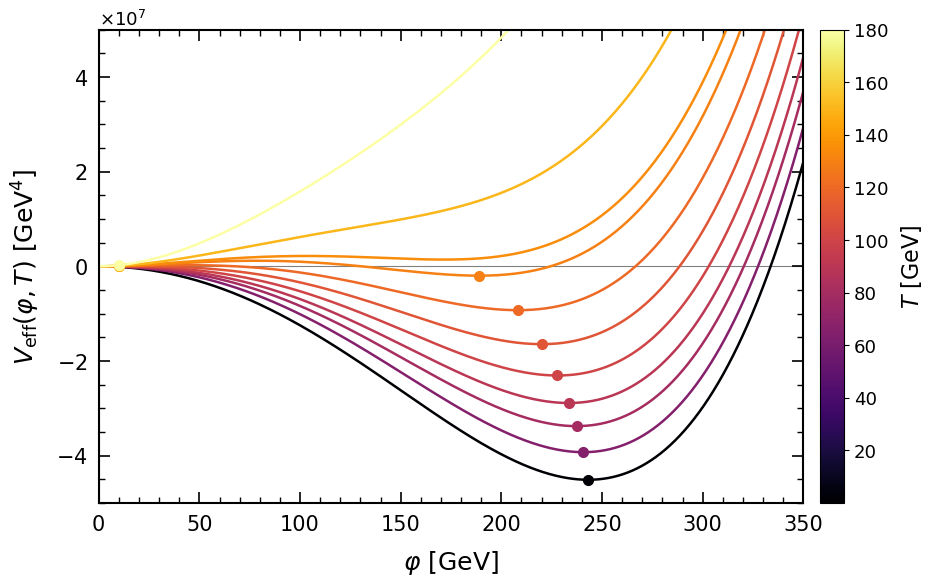

In [296]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# ── Temperature sample ──────────────────────────────────────────────────────
# Start rough, refine once you know Tc from findTc()
T_vals = np.array([1e-6, 65, 80, 90, 100, 110, 120, 130, 135, 150, 180])   # GeV

phi_vals = np.linspace(-10, 500, 1500)
X        = phi_vals[:, np.newaxis]

# ── Colormap: cool = low T, warm = high T ───────────────────────────────────
cmap  = plt.cm.inferno
norm  = Normalize(vmin=T_vals.min(), vmax=T_vals.max())
sm    = ScalarMappable(cmap=cmap, norm=norm)

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9.71, 6))

ax.axhline(0, color='gray', lw=0.8, ls='-', zorder=0)
ax.axvline(0, color='gray', lw=0.8, ls='-', zorder=0)

for T in T_vals:
    V = model.Vtot(X, T)
    V_norm = V - model.Vtot(np.array([[0.0]]), T)   # shift so V(φ=0, T) = 0
    color = cmap(norm(T))
    label = r'$T = 0$' if T < 1 else rf'$T = {T:.0f}$ GeV'
    ax.plot(phi_vals, V_norm, color=color, lw=1.8, label=label)

    # Mark the minimum of the broken phase
    mask = phi_vals > 10          # ignore the origin region
    idx  = np.argmin(V[mask])
    phi_min = phi_vals[mask][idx]
    V_min   = V[mask][idx]
    ax.plot(phi_min, V_min-model.Vtot(np.array([[0.0]]), T), 'o', color=color, ms=7, zorder=5)

# ── Colorbar instead of legend (cleaner for many curves) ────────────────────
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r'$T\ [\mathrm{GeV}]$', fontsize=16, labelpad=8)
cbar.ax.tick_params(labelsize=13)

# ── Axes ─────────────────────────────────────────────────────────────────────
ax.set_xlim(0, 350)
ax.set_ylim(-5e7,5e7)
ax.set_xlabel(r'$\varphi\ [\mathrm{GeV}]$',                   fontsize=18, labelpad=10)
ax.set_ylabel(r'$V_\mathrm{eff}(\varphi,T)\ [\mathrm{GeV}^4]$', fontsize=18, labelpad=10)

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(13)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8,  width=1.2,
               labelsize=15, top=True, right=True, pad=8)
ax.tick_params(axis='both', which='minor', direction='in', length=4,  width=1.0,
               labelsize=15, top=True, right=True)
ax.minorticks_on()

plt.tight_layout(pad=1.2)
plt.savefig(r"figures\Abelian_thermal.pdf", format="pdf", bbox_inches="tight")
plt.show()